## Реализация PCA

In [1]:
import pandas as pd
import numpy as np
import copy
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, v_measure_score, adjusted_rand_score

### Чтение данных

In [2]:
data = pd.read_csv('../data/credit_card_fraud_filtered.csv')

y = data['fraud']
x = data.drop('fraud', axis=1)

### Сбор метрик

In [3]:
results = []

def test(x_test, y=y):
    pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', BaggingClassifier(
        n_estimators=15,
        max_samples=0.67,
        max_features=0.91,
        random_state=81,
        n_jobs=-1
    ))
])

    kf = KFold(n_splits=5, shuffle=True, random_state=81)

    y_pred = cross_val_predict(pipeline, x_test, y, cv=kf, n_jobs=-1)
    f1 = f1_score(y, y_pred)

    print(f"Средняя f1-score: {round(f1, 4)}")
    print(classification_report(y, y_pred))
    print(confusion_matrix(y, y_pred))
    
    return round(f1, 4)

### Масштабирование данных

In [4]:
scaler = StandardScaler()
x_pca_custom = scaler.fit_transform(x)
x_pca_custom = pd.DataFrame(x_pca_custom, columns=x.columns)

x_pca_custom.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,high_price_anomaly
0,1.344313,-0.508417,0.227062,0.338084,1.361498,-0.334409,-1.363986,-0.237364
1,-0.352543,-0.532761,-0.173618,0.338084,-0.734485,-0.334409,-1.363986,-0.237364
2,-0.559524,-0.419695,-0.706349,0.338084,-0.734485,-0.334409,0.733145,-0.237364
3,-0.662080,0.441445,-0.746343,0.338084,1.361498,-0.334409,0.733145,-0.237364
4,0.850673,-0.462558,0.397257,0.338084,1.361498,-0.334409,0.733145,-0.237364


### Использование библиотечного PCA 

In [5]:
pca = PCA(n_components=4)
x_pca = pca.fit_transform(x_pca_custom)
f1_pca = test(x_pca)

Средняя f1-score: 0.9643
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    828124
           1       1.00      0.93      0.96     56670

    accuracy                           1.00    884794
   macro avg       1.00      0.97      0.98    884794
weighted avg       1.00      1.00      1.00    884794

[[828084     40]
 [  3870  52800]]


In [6]:
results.append({"Method": "PCA", "f1": f1_pca})

Проверим `n_components`=2.

In [7]:
pca_2 = PCA(n_components=2)
x_pca_2 = pca_2.fit_transform(x_pca_custom)
f1_pca_2 = test(x_pca_2)

Средняя f1-score: 0.1845
              precision    recall  f1-score   support

           0       0.94      0.99      0.97    828124
           1       0.59      0.11      0.18     56670

    accuracy                           0.94    884794
   macro avg       0.76      0.55      0.58    884794
weighted avg       0.92      0.94      0.92    884794

[[823721   4403]
 [ 50463   6207]]


### Самостоятельная реализация PCA

In [8]:
def pca_method(x, k=2):
    x = x.to_numpy()
    mean = x.mean(axis=0)
    std = x.std(axis=0)
    x = (x - mean) / (std + 1e-9)

    n = len(x)
    cov_matrix = (x.T @ x) / (n - 1)

    eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

    idx = eigen_values.argsort()[::-1][:k]

    eigen_vectors = eigen_vectors[:, idx]

    x_reduced = x_pca_custom @ eigen_vectors
    
    return pd.DataFrame(x_reduced)

In [9]:
x_pca_custom = pca_method(x_pca_custom, k=4)

f1_pca_custom = test(x_pca_custom)

Средняя f1-score: 0.9644
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    828124
           1       1.00      0.93      0.96     56670

    accuracy                           1.00    884794
   macro avg       1.00      0.97      0.98    884794
weighted avg       1.00      1.00      1.00    884794

[[828084     40]
 [  3859  52811]]


In [10]:
results.append({"Method": "Custom PCA", "f1": f1_pca})

### Вывод

In [11]:
res = pd.DataFrame(results)
res

,Method,f1
0,PCA,0.9643
1,Custom PCA,0.9643


Классный у меня PCA получился!

### k-Means

In [18]:
results_kmeans = []

def metrics(x, labels, y):
    calinski_harabasz = calinski_harabasz_score(x, labels) 
    sil_score = silhouette_score(x, labels)
    v_score = v_measure_score(y, labels)
    adjusted_rand = adjusted_rand_score(y, labels)

    metrics_for_trial = {
        'Silhouette': round(sil_score, 4),
        'Calinski-Harabasz': round(calinski_harabasz, 4),
        'V-Measure': round(v_score, 4),
        'ARI': round(adjusted_rand, 4)
    }

    return metrics_for_trial

In [19]:
y = y.head(50_000).copy()
x = x_pca_custom.head(50_000).copy()

In [15]:
def Kmeans(array, k, max_iter=1000, tol=1e-4):      # tol - порог сходимости
    data = np.array(array)
    n = data.shape[0]
    
    indices = np.random.choice(n, size=k, replace=False)    # k случайных индексов из диапазона от 0 до n без повторений
    centroids = data[indices].tolist()
    
    for _ in range(max_iter):
        labels = data_distribution(data, centroids)
        
        old_centroids = copy.deepcopy(centroids)    # deepcopy нужен, чтобы изменение списка centroids не затронуло old_centroids
        
        centroids = cluster_update(data, labels, k)
        
        if np.allclose(old_centroids, centroids, atol=tol):
            break
    
    return labels, centroids

def data_distribution(data, centroids):     # вычисляем евклидово расстояние от точки до конкретного центра c
    return [np.argmin([np.linalg.norm(point - c) for c in centroids]) 
            for point in data]

def cluster_update(data, labels, k):
    new_centroids = []
    for i in range(k):
        cluster_points = data[labels == i]
        if len(cluster_points) == 0:        # если к центру никто не «пришел», мы принудительно переносим его на координаты любой случайной точки из датасета
            new_centroids.append(data[np.random.randint(len(data))].tolist())
            continue
        new_centroids.append(cluster_points.mean(axis=0).tolist())
    return new_centroids

Кластер 0: число наблюдений 27975
Кластер 1: число наблюдений 13465
Кластер 2: число наблюдений 6600
Кластер 3: число наблюдений 1960


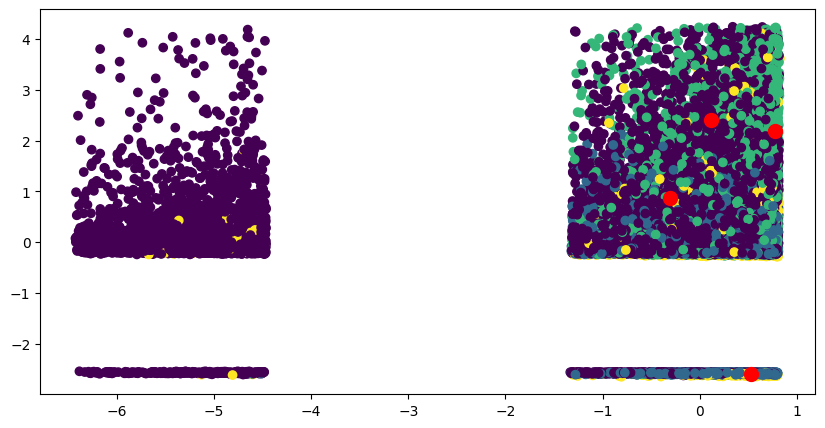

In [20]:
labels, centroids = Kmeans(x, 4, 1000)

centroids = np.array(centroids)

metrics_result = metrics(
    x=x, 
    labels=labels, 
    y=y
)
results_kmeans.append(metrics_result)
   
unique, counts = np.unique(labels, return_counts=True)
for key, value in zip(unique, counts):
    print(f"Кластер {key}: число наблюдений {value}")

x['cluster_id'] = labels

plt.figure(figsize=(10, 5))
plt.scatter(x.iloc[:,0], x.iloc[:,1], c=labels)
plt.scatter(centroids[:,0], centroids[:,1], s=100, c='red')
plt.show()

In [21]:
res_k = pd.DataFrame(results_kmeans)
res_k

,Silhouette,Calinski-Harabasz,V-Measure,ARI
0,0.1124,5854.0184,0.0222,-0.0374
